In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from hydrosense.database.ades import GestionnairePiezometrie

### Téléchargement Piezo

- Nouveau Code National BSS : BSS001QHYH
- Ancien Code BSS (Indice) : 06352X0032/S
- Nom sur les bases de données (ADES / HubEAU) : BOURDET (situé au lieu-dit La Jannerie)
- Entité Hydrogéologique : Calcaires du Jurassique supérieur (Aquifère du secteur Aunis)

In [86]:
bss_id = 'BSS001QHYH'

gestionnaire = GestionnairePiezometrie(dossier_sortie="../raw_data")
gestionnaire.telecharger_bassin_versant([bss_id])

--- Début du traitement pour 1 forages ---
Info: données BSS001QHYH déja présente
--- Traitement du bassin versant terminé ! ---


In [87]:
df = pd.read_csv(f'../raw_data/piezo_{bss_id}.csv', sep = ';')
# df = df.set_index('date_mesure')
df['date_mesure'] = pd.to_datetime(df['date_mesure'])

df.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1985-06-24,12.54,2.68
1,1985-06-25,12.54,2.68
2,1985-06-26,12.54,2.68
3,1985-06-27,12.54,2.68
4,1985-06-28,12.51,2.71


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14532 entries, 0 to 14531
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mesure       14532 non-null  datetime64[ns]
 1   niveau_nappe_eau  14532 non-null  float64       
 2   profondeur_nappe  14532 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 340.7 KB


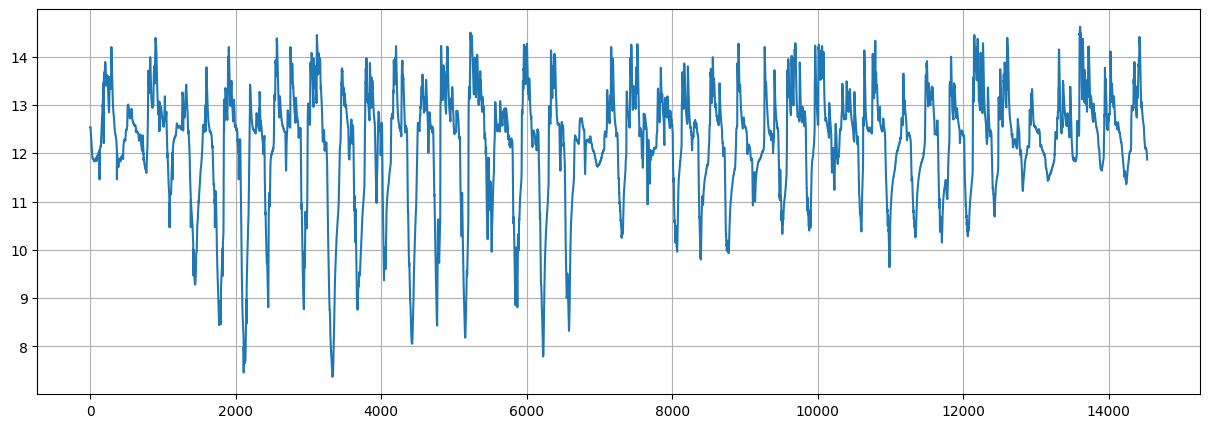

In [89]:
df['niveau_nappe_eau'].plot(kind = 'line', figsize=(15,5))
plt.grid(True)

In [90]:
df.shape

(14532, 3)

In [91]:
df

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1985-06-24,12.54,2.68
1,1985-06-25,12.54,2.68
2,1985-06-26,12.54,2.68
3,1985-06-27,12.54,2.68
4,1985-06-28,12.51,2.71
...,...,...,...
14527,2026-05-26,12.00,4.17
14528,2026-05-27,11.96,4.21
14529,2026-05-28,11.93,4.24
14530,2026-05-29,11.89,4.28


In [92]:
df['niveau_nappe_eau'].value_counts()

niveau_nappe_eau
12.54    113
12.57    111
12.47    109
12.44    107
12.51    106
        ... 
8.21       1
8.27       1
14.48      1
14.50      1
14.36      1
Name: count, Length: 692, dtype: int64

In [93]:
df.isnull().sum().sort_values(ascending=False) / len(df)

date_mesure         0.0
niveau_nappe_eau    0.0
profondeur_nappe    0.0
dtype: float64

In [94]:
# Compter le total
total_nan = df['niveau_nappe_eau'].isna().sum()
print(f"Total de NaNs : {total_nan}")

# Calculer la taille des blocs de NaNs consécutifs
nan_groups = df['niveau_nappe_eau'].notna().cumsum()
trous_tailles = df['niveau_nappe_eau'].isna().groupby(nan_groups).sum()
print("\nDescription des tailles de trous (en lignes) :")
print(trous_tailles[trous_tailles > 0].describe())

Total de NaNs : 0

Description des tailles de trous (en lignes) :
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: niveau_nappe_eau, dtype: float64


In [95]:
total_nan = df['niveau_nappe_eau'].isna().sum()
pourcentage_nan = df['niveau_nappe_eau'].isna().mean() * 100

print(f"Nombre de NaNs : {total_nan}")
print(f"Pourcentage de NaNs : {pourcentage_nan:.2f}%")

Nombre de NaNs : 0
Pourcentage de NaNs : 0.00%


In [96]:
# 2. Créer le calendrier théorique parfait (sans aucun trou)
date_min = df['date_mesure'].min()
date_max = df['date_mesure'].max()
calendrier_parfait = pd.date_range(start=date_min, end=date_max, freq='D')

# 3. Trouver les dates du calendrier qui ne sont PAS dans ton dataframe
dates_absentes = calendrier_parfait.difference(df['date_mesure'])

print(f"Il y a {len(dates_absentes)} dates complètement absentes de ton fichier.")
if len(dates_absentes) > 0:
    print("Exemples de dates manquantes :")
    print(dates_absentes[:10]) # Affiche les 10 premières

Il y a 419 dates complètement absentes de ton fichier.
Exemples de dates manquantes :
DatetimeIndex(['1985-07-16', '1985-07-18', '1985-08-16', '1985-08-18',
               '1985-09-16', '1985-09-18', '1985-10-16', '1985-10-18',
               '1985-11-16', '1985-11-18'],
              dtype='datetime64[ns]', freq=None)


In [97]:
df.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1985-06-24,12.54,2.68
1,1985-06-25,12.54,2.68
2,1985-06-26,12.54,2.68
3,1985-06-27,12.54,2.68
4,1985-06-28,12.51,2.71


In [98]:
dates_absentes

DatetimeIndex(['1985-07-16', '1985-07-18', '1985-08-16', '1985-08-18',
               '1985-09-16', '1985-09-18', '1985-10-16', '1985-10-18',
               '1985-11-16', '1985-11-18',
               ...
               '2024-11-09', '2024-11-10', '2024-11-11', '2024-11-12',
               '2024-11-13', '2024-11-14', '2024-11-15', '2024-11-16',
               '2024-11-17', '2024-11-18'],
              dtype='datetime64[ns]', length=419, freq=None)

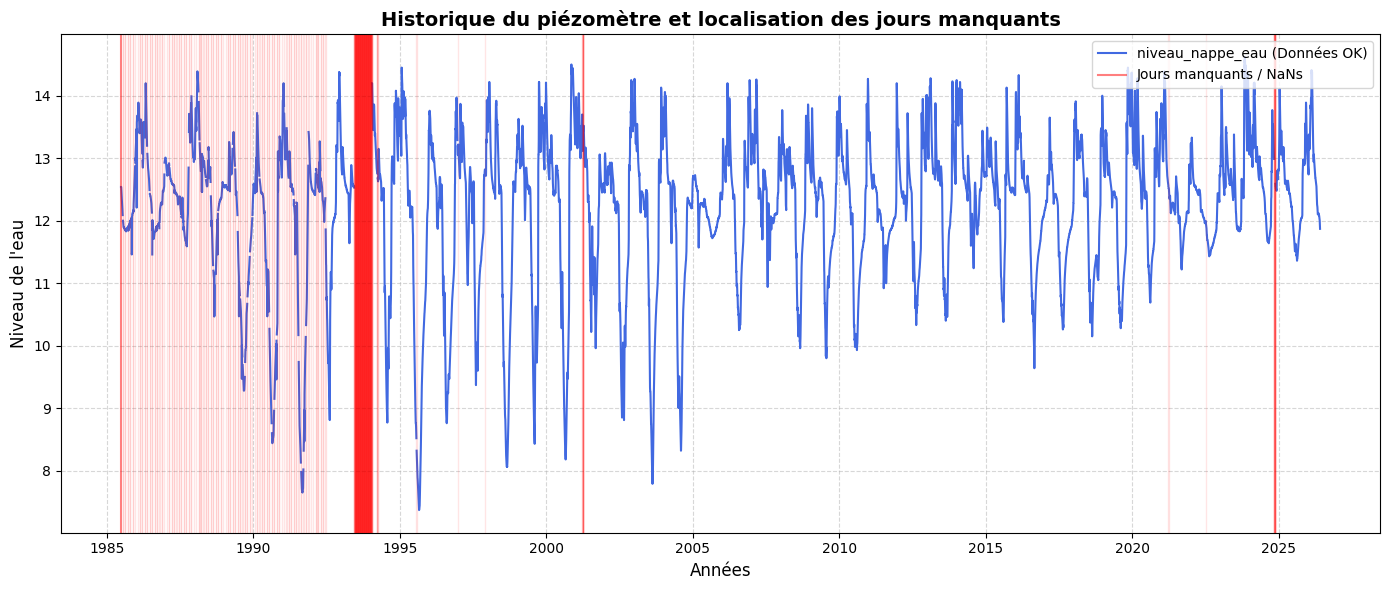

In [99]:
# Cela va forcer les dates manquantes à devenir des lignes physiques remplies de NaNs
df_complet = df.set_index('date_mesure').reindex(calendrier_parfait)

#Tracer le graphique
plt.figure(figsize=(14, 6))

# En bleu : Le niveau de la nappe (les données que tu possèdes)
plt.plot(df_complet.index, df_complet['niveau_nappe_eau'],
         color='royalblue', label='niveau_nappe_eau (Données OK)', linewidth=1.5)

# En rouge : On affiche de grands traits verticaux là où il n'y a AUCUNE donnée
# (cumul des NaNs d'origine et des dates qui étaient absentes)
manques = df_complet['niveau_nappe_eau'].isna()
for date_manquante in df_complet[manques].index:
    plt.axvline(x=date_manquante, color='red', alpha=0.1, linestyle='-', linewidth=1)

# Hack pour afficher une seule légende "Données manquantes" pour les lignes rouges
plt.axvline(x=df_complet.index[0], color='red', alpha=0.5, label='Jours manquants / NaNs')

# Personnalisation du graphique
plt.title("Historique du piézomètre et localisation des jours manquants", fontsize=14, fontweight='bold')
plt.xlabel("Années", fontsize=12)
plt.ylabel("Niveau de l'eau", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

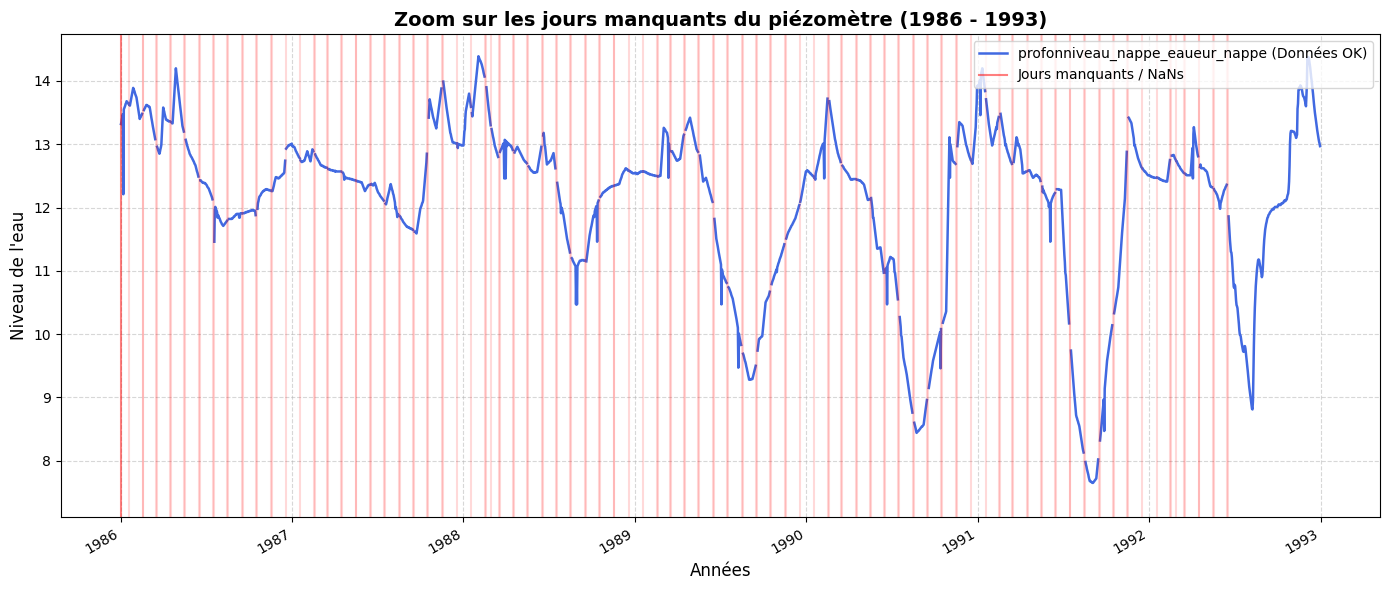

In [100]:
df_zoom = df_complet.loc['1986-01-01':'1992-12-31']

# Tracer le graphique zoomé
plt.figure(figsize=(14, 6))

# Courbe bleue : les données existantes sur cette période
plt.plot(df_zoom.index, df_zoom['niveau_nappe_eau'],
         color='royalblue', label='profonniveau_nappe_eaueur_nappe (Données OK)', linewidth=1.8)

# Barres rouges : localisation des NaNs et dates absentes entre 86 et 93
manques_zoom = df_zoom['niveau_nappe_eau'].isna()
for date_manquante in df_zoom[manques_zoom].index:
    plt.axvline(x=date_manquante, color='red', alpha=0.15, linestyle='-', linewidth=1.5)

# Ligne rouge invisible juste pour générer la légende proprement
plt.axvline(x=df_zoom.index[0], color='red', alpha=0.5, label='Jours manquants / NaNs')

# Personnalisation du rendu
plt.title("Zoom sur les jours manquants du piézomètre (1986 - 1993)", fontsize=14, fontweight='bold')
plt.xlabel("Années", fontsize=12)
plt.ylabel("Niveau de l'eau", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Amélioration de l'affichage des dates sur l'axe X
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

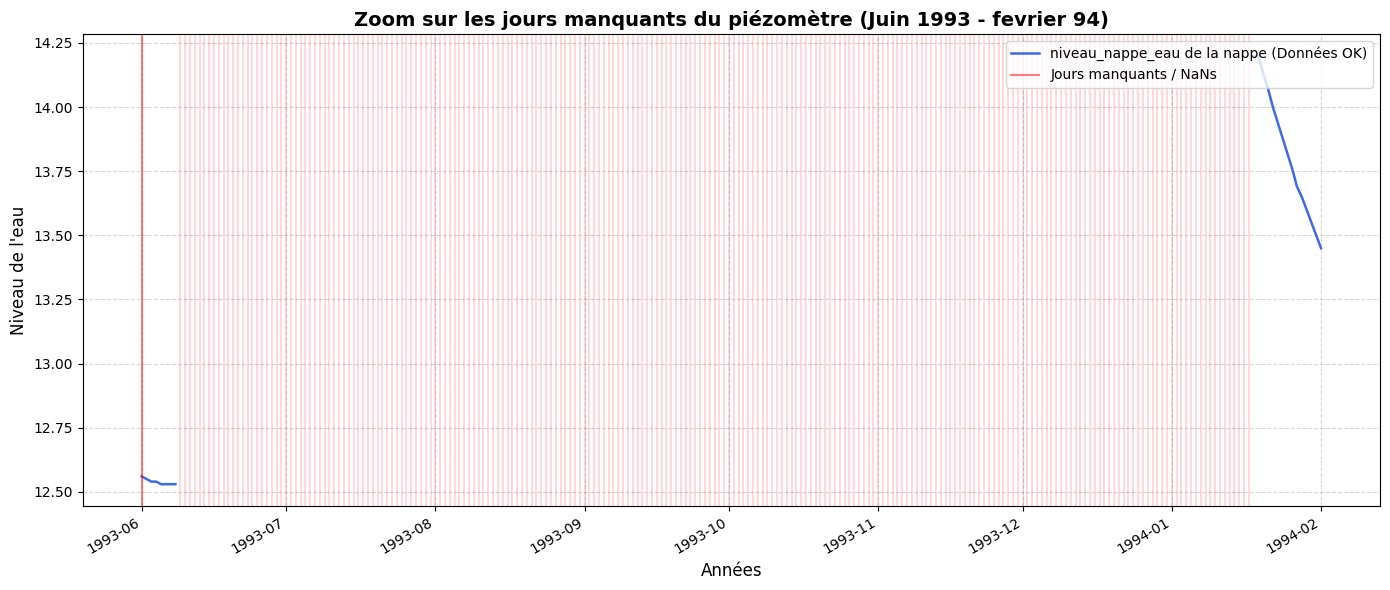

In [101]:
df_zoom = df_complet.loc['1993-06-01':'1994-02-01']

# 5. Tracer le graphique zoomé
plt.figure(figsize=(14, 6))

# Courbe bleue : les données existantes sur cette période
plt.plot(df_zoom.index, df_zoom['niveau_nappe_eau'],
         color='royalblue', label='niveau_nappe_eau de la nappe (Données OK)', linewidth=1.8)

# Barres rouges : localisation des NaNs et dates absentes entre 86 et 93
manques_zoom = df_zoom['niveau_nappe_eau'].isna()
for date_manquante in df_zoom[manques_zoom].index:
    plt.axvline(x=date_manquante, color='red', alpha=0.15, linestyle='-', linewidth=1.5)

# Ligne rouge invisible juste pour générer la légende proprement
plt.axvline(x=df_zoom.index[0], color='red', alpha=0.5, label='Jours manquants / NaNs')

# Personnalisation du rendu
plt.title("Zoom sur les jours manquants du piézomètre (Juin 1993 - fevrier 94)", fontsize=14, fontweight='bold')
plt.xlabel("Années", fontsize=12)
plt.ylabel("Niveau de l'eau", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Amélioration de l'affichage des dates sur l'axe X
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [102]:
jours_manquants = manques_zoom.sum()
print(f"Il manque {jours_manquants} jours de relevé sur cette période.")

Il manque 223 jours de relevé sur cette période.


ON démarre donc en Fevrier 1994

In [103]:

# 2. On applique le filtre sur la colonne directement
df_lebest = df[
    (df['date_mesure'] >= '1994-02-01') &
    (df['date_mesure'] <= df['date_mesure'].max())
]

# 3. On affiche les premières lignes
df_lebest.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
2765,1994-02-01,13.45,1.77
2766,1994-02-02,13.55,1.67
2767,1994-02-03,13.79,1.43
2768,1994-02-04,13.80,1.42
2769,1994-02-05,13.79,1.43


In [104]:
# 1. On réinitialise l'index à 0 et on supprime l'ancienne colonne d'index (drop=True)
df_lebest = df_lebest.reset_index(drop=True)

# On vérifie le résultat
df_lebest.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1994-02-01,13.45,1.77
1,1994-02-02,13.55,1.67
2,1994-02-03,13.79,1.43
3,1994-02-04,13.80,1.42
4,1994-02-05,13.79,1.43


<Axes: xlabel='date_mesure'>

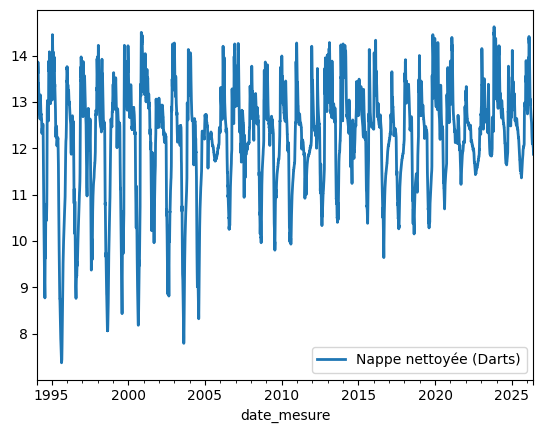

In [105]:
from darts.dataprocessing.transformers import MissingValuesFiller
from darts import TimeSeries

series = TimeSeries.from_dataframe(
    df_lebest,
    time_col='date_mesure',
    value_cols='niveau_nappe_eau',
    fill_missing_dates=True,
    freq='D'
)

# Initialiser le remplisseur (par défaut, il fait une interpolation linéaire)
filler = MissingValuesFiller()

# Créer une série complètement propre, sans aucun NaN
series_clean = filler.transform(series)

# Tu peux vérifier le résultat graphique
series_clean.plot(label="Nappe nettoyée (Darts)")

In [106]:
series_clean.dtype

dtype('float64')

In [107]:
series_clean.head(20)

,niveau_nappe_eau
date_mesure,
1994-02-01,13.45
1994-02-02,13.55
1994-02-03,13.79
1994-02-04,13.80
1994-02-05,13.79
...,...
1994-02-16,13.72
1994-02-17,13.66
1994-02-18,13.60


In [108]:
import os

In [109]:
# L'index du DataFrame sera ta colonne temporelle ('date_mesure')
df_processed = series_clean.to_dataframe()

# Optionnel : Si tu veux que 'date_mesure' redevienne une colonne normale et pas l'index (recommandé pour BigQuery)
df_processed = df_processed.reset_index()

# ==========================================
# EXPORT 1 : VERS UN FICHIER CSV
# ==========================================
df_processed.to_csv("./data/piezo_bourdet_clean.csv", index=False)
